In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
df = pd.read_csv("table_group_params.csv")
rproj_fit_mult=df.rproj_fit_mult.to_numpy()
vproj_fit_mult=df.vproj_fit_mult.to_numpy()
vproj_fit_offset=df.vproj_fit_offset.to_numpy()
gdrproj_fit_mult=df.gd_rproj_fit_mult.to_numpy()
gdvproj_fit_mult=df.gd_vproj_fit_mult.to_numpy()
gdvproj_fit_offset=df.gd_vproj_fit_offset.to_numpy()
labels=["({a:d},{b:d},{c:d},{d:d},{e:d},{f:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii], d=gdrproj_fit_mult[ii], e=gdvproj_fit_mult[ii], f=gdvproj_fit_offset[ii]) for ii in range(0,len(df))]
labels_for_giant_params=["({a:d}, {b:d}, {c:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii]) for ii in range(0,len(df))]
df.loc[:,'labels_giant_params']=labels_for_giant_params

dwarflabels=["({a:d}, {b:d}, {c:d})".format(a=gdrproj_fit_mult[ii], b=gdvproj_fit_mult[ii], c=gdvproj_fit_offset[ii]) for ii in range(0,len(df))]
df.loc[:,'dwarfparamlabels']=dwarflabels
df.set_index('dwarfparamlabels')

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups,labels_giant_params
dwarfparamlabels,,,,,,,,,,,,,,,,,,,,,
"(1, 1, 0)",1,1,100,1,1,0,0.172,0.220764,0.208,0.995066,...,0.990390,0.919929,1.000000,0.917901,0.995370,0.921605,0.1635,8754,54,"(1, 1, 100)"
"(1, 1, 100)",1,1,100,1,1,100,0.171,0.220764,0.208,0.995044,...,0.990390,0.922936,1.000000,0.935587,0.995215,0.944279,0.1535,8706,102,"(1, 1, 100)"
"(1, 1, 200)",1,1,100,1,1,200,0.171,0.220764,0.208,0.995044,...,0.990390,0.922936,1.000000,0.935587,0.995215,0.944279,0.1535,8706,102,"(1, 1, 100)"
"(1, 1, 300)",1,1,100,1,1,300,0.171,0.220764,0.208,0.995044,...,0.990390,0.922936,1.000000,0.935587,0.995215,0.944279,0.1535,8706,102,"(1, 1, 100)"
"(1, 2, 0)",1,1,100,1,2,0,0.172,0.220764,0.208,0.995051,...,0.990390,0.921952,1.000000,0.924481,0.994390,0.934671,0.1550,8721,87,"(1, 1, 100)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 300)",6,6,300,6,5,300,0.211,0.908734,0.521,0.952965,...,0.951532,0.989460,0.833237,0.985859,0.692345,0.988729,0.2940,5394,575,"(6, 6, 300)"
"(6, 6, 0)",6,6,300,6,6,0,0.211,0.931467,0.521,0.952779,...,0.951493,0.989512,0.833237,0.985859,0.692345,0.988729,0.2940,5390,575,"(6, 6, 300)"
"(6, 6, 100)",6,6,300,6,6,100,0.211,0.908734,0.521,0.953049,...,0.951237,0.989378,0.832658,0.985884,0.691881,0.988756,0.2945,5397,576,"(6, 6, 300)"


In [3]:
dwarfresults = df[df.labels_giant_params=='(3, 4, 200)']
dwarfresults=dwarfresults.sample(frac=0.5)
dwarfresults=dwarfresults.set_index('dwarfparamlabels')

dwarfresults

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups,labels_giant_params
dwarfparamlabels,,,,,,,,,,,,,,,,,,,,,
"(1, 5, 100)",3,4,200,1,5,100,0.162,0.400711,0.225,0.989551,...,0.992786,0.949527,0.963889,0.961538,0.884354,0.965986,0.2115,7339,130,"(3, 4, 200)"
"(6, 4, 100)",3,4,200,6,4,100,0.164,0.400711,0.225,0.985202,...,0.982450,0.972245,0.921605,0.972498,0.850187,0.974121,0.1955,6931,504,"(3, 4, 200)"
"(1, 6, 100)",3,4,200,1,6,100,0.162,0.400711,0.225,0.989550,...,0.992641,0.949527,0.963889,0.961538,0.884354,0.965986,0.2115,7338,130,"(3, 4, 200)"
"(5, 4, 300)",3,4,200,5,4,300,0.163,0.400711,0.225,0.986376,...,0.985748,0.970272,0.935865,0.969162,0.874457,0.971165,0.1920,6984,463,"(3, 4, 200)"
"(4, 5, 300)",3,4,200,4,5,300,0.164,0.400711,0.225,0.987477,...,0.988457,0.967490,0.949314,0.970919,0.895060,0.976995,0.1930,7047,405,"(3, 4, 200)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(1, 3, 300)",3,4,200,1,3,300,0.162,0.400711,0.225,0.989530,...,0.992638,0.949593,0.962607,0.961538,0.878378,0.966216,0.2115,7336,130,"(3, 4, 200)"
"(2, 1, 0)",3,4,200,2,1,0,0.162,0.400711,0.225,0.989314,...,0.992190,0.949288,0.947222,0.955128,0.855263,0.961623,0.2160,7334,130,"(3, 4, 200)"
"(2, 2, 200)",3,4,200,2,2,200,0.162,0.400711,0.225,0.989044,...,0.991897,0.957062,0.965714,0.973501,0.908745,0.975919,0.1815,7224,239,"(3, 4, 200)"


In [4]:
#dwarfresults = dwarfresults[dwarfresults.gd_rproj_fit_mult>1]
#dwarfresults
dwarfresults.sort_values(by='gd_rproj_fit_mult')

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups,labels_giant_params
dwarfparamlabels,,,,,,,,,,,,,,,,,,,,,
"(1, 5, 100)",3,4,200,1,5,100,0.162,0.400711,0.225,0.989551,...,0.992786,0.949527,0.963889,0.961538,0.884354,0.965986,0.21150,7339,130,"(3, 4, 200)"
"(1, 6, 100)",3,4,200,1,6,100,0.162,0.400711,0.225,0.989550,...,0.992641,0.949527,0.963889,0.961538,0.884354,0.965986,0.21150,7338,130,"(3, 4, 200)"
"(1, 3, 300)",3,4,200,1,3,300,0.162,0.400711,0.225,0.989530,...,0.992638,0.949593,0.962607,0.961538,0.878378,0.966216,0.21150,7336,130,"(3, 4, 200)"
"(1, 1, 200)",3,4,200,1,1,200,0.162,0.400711,0.225,0.989530,...,0.992638,0.949593,0.962607,0.961538,0.878378,0.966216,0.21150,7336,130,"(3, 4, 200)"
"(1, 3, 100)",3,4,200,1,3,100,0.161,0.400711,0.225,0.989552,...,0.992786,0.949526,0.963889,0.961538,0.884354,0.965986,0.21150,7339,130,"(3, 4, 200)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 6, 0)",3,4,200,6,6,0,0.164,0.400711,0.225,0.985202,...,0.982450,0.972245,0.921605,0.972498,0.850187,0.974121,0.19550,6931,504,"(3, 4, 200)"
"(6, 4, 300)",3,4,200,6,4,300,0.164,0.400711,0.225,0.985222,...,0.982597,0.972245,0.921936,0.972498,0.851616,0.974078,0.19550,6932,504,"(3, 4, 200)"
"(6, 4, 100)",3,4,200,6,4,100,0.164,0.400711,0.225,0.985202,...,0.982450,0.972245,0.921605,0.972498,0.850187,0.974121,0.19550,6931,504,"(3, 4, 200)"


In [5]:
max(dwarfresults.n_Ngt1dwgroups), min(dwarfresults.n_Ngt1dwgroups)

(504, 130)

In [6]:
np.max(dwarfresults.mu_HME_dwgt1)-np.min(dwarfresults.mu_HME_dwgt1)

0.034499999999999614

In [7]:
pg=dwarfresults.P_G_dw.to_numpy()
pggt1=dwarfresults.P_G_dwgt1.to_numpy()
cg=dwarfresults.C_G_dw.to_numpy()
cggt1=dwarfresults.C_G_dwgt1.to_numpy()
ph=dwarfresults.P_H_dw.to_numpy()
phgt1=dwarfresults.P_H_dwgt1.to_numpy()
ch=dwarfresults.C_H_dw.to_numpy()
chgt1=dwarfresults.C_H_dwgt1.to_numpy()
mu=dwarfresults.mu_HME_dw.to_numpy()
mugt1=dwarfresults.mu_HME_dwgt1.to_numpy()
pgtimescg=pg*cg
phtimesch=ph*ch
pggt1timescggt1=pggt1*cggt1
phgt1timeschgt1=phgt1*chgt1

order=np.argsort(pgtimescg)
pg=pg[order]
cg=cg[order]
ch=ch[order]
ph=ph[order]
pggt1=pggt1[order]
cggt1=cggt1[order]
phgt1=phgt1[order]
chgt1=chgt1[order]
mu=mu[order]
mugt1=mugt1[order]
phtimesch=phtimesch[order]
pgtimescg=pgtimescg[order]
pggt1timescggt1=pggt1timescggt1[order]
phgt1timeschgt1=phgt1timeschgt1[order]
newlabels=np.array(dwarfresults.index.to_numpy())[order]

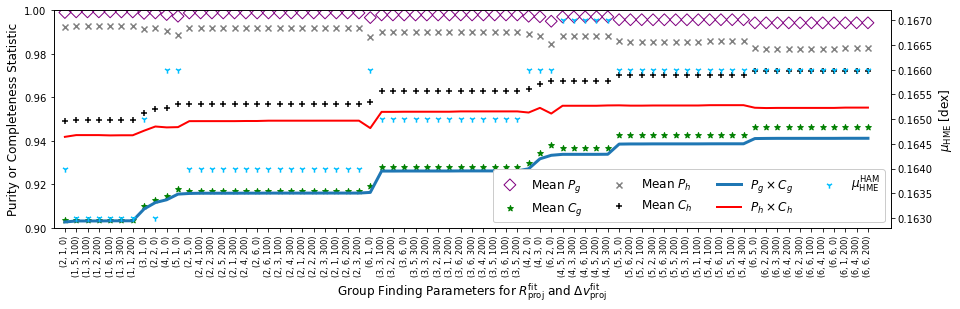

In [8]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,4))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
ax.set_ylim(0.9,1.0)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
ax1=ax.twinx()
ax1.scatter(myrange-1,mu,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
#ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
#ax1.set_ylim(0.15,0.18)
#plt.xlim(50,100)
ax.legend(loc='lower right', framealpha=1, fontsize=12, ncol=4)
plt.show()

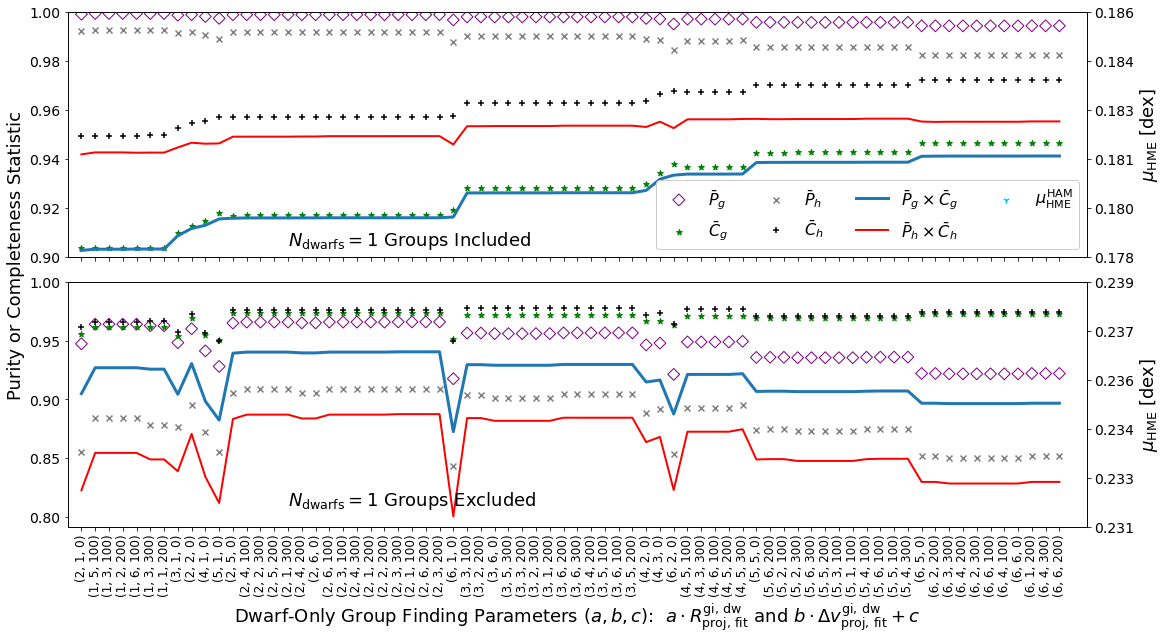

In [9]:
fig,(ax,ax1)=plt.subplots(figsize=(16,9),nrows=2,sharex=True)
myrange=np.arange(1,len(pg)+1)
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label=r'$\bar{P}_g$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label=r'$\bar{C}_g$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label=r'$\bar{P}_h$')
ax.scatter(myrange-1,ch,color='k',marker='+', label=r'$\bar{C}_h$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$\bar{P}_g \times \bar{C}_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$\bar{P}_h \times \bar{C}_h$')
ax.set_xlim(-1,max(myrange)+1)
axtwin=ax.twinx()
axtwin.scatter(myrange-1,mu,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
axtwin.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=18)
ax.legend(loc='lower right', framealpha=1, fontsize=16, ncol=4)
ax.set_ylim(0.9,1.)
ytvals = np.arange(0.9,1.005,0.02)
ax.set_yticks(ytvals, ["{:0.2f}".format(x) for x in ytvals], fontsize=14)
hme_ylim = [0.178,0.186]
step=(hme_ylim[1]-hme_ylim[0])/5.
axtwin.set_ylim(*hme_ylim)
hme_ytvals = np.arange(hme_ylim[0],hme_ylim[1]+step,step)
axtwin.set_yticks(hme_ytvals, ["{:0.3f}".format(x) for x in hme_ytvals], fontsize=14)

ax1.scatter(myrange-1,pggt1,edgecolors='purple',facecolors='None',marker='D',label='r$\bar{P}_g$',s=70)
ax1.scatter(myrange-1,cggt1,color='green',marker='*', label='r$\bar{C}_g$')
ax1.scatter(myrange-1,phgt1,color='gray',marker='x', label=r'$\bar{P}_h$')
ax1.scatter(myrange-1,chgt1,color='k',marker='+', label=r'$\bar{C}_h$',s=30)
ax1.plot(myrange-1,pggt1timescggt1,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax1.plot(myrange-1,phgt1timeschgt1,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax1twin=ax1.twinx()
ax1twin.scatter(myrange-1,mugt1,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1twin.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=18)
#ax1.set_ylim(0.8,1)
ytvals = np.arange(0.8,1.05,0.05)
ax1.set_yticks(ytvals, ["{:0.2f}".format(x) for x in ytvals], fontsize=14)
hme_ylim = [0.231,0.239]
step=(hme_ylim[1]-hme_ylim[0])/5.
ax1twin.set_ylim(*hme_ylim)
hme_ytvals = np.arange(hme_ylim[0],hme_ylim[1]+step,step)
ax1twin.set_yticks(hme_ytvals, ["{:0.3f}".format(x) for x in hme_ytvals], fontsize=14)

ax1.set_xlabel(r"Dwarf-Only Group Finding Parameters $(a,b,c)$:  $a\cdot R_{\rm proj,\, fit}^{\rm gi,\, dw}$ and $b \cdot \Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}+c$",fontsize=18)
ax1.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=12)
fig.text(-0.01, 0.6, 'Purity or Completeness Statistic', va='center', rotation='vertical',fontsize=18)

#ax.annotate(r"Parameters $(a,b,c)$:  $a\cdot R_{\rm proj,\, fit}^{\rm gi,\, dw}$ and $b \cdot \Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}+c$",\
#            xy=(7,0.945),fontsize=18)
ax.annotate(r"$N_{\rm dwarfs}=1$ Groups Included",xy=(15,0.905),fontsize=18)
ax1.annotate(r"$N_{\rm dwarfs}=1$ Groups Excluded",xy=(15,0.81),fontsize=18)
plt.tight_layout()
plt.savefig("../figures/optimal_params_dwarfs.pdf",dpi=300)
plt.show()

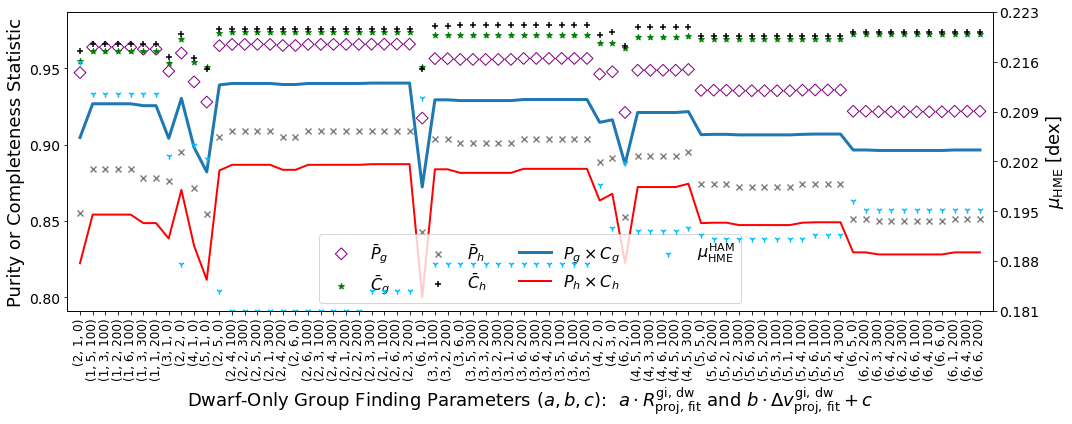

In [10]:
fig,(ax1)=plt.subplots(figsize=(15,6),sharex=True)
myrange=np.arange(1,len(pg)+1)
ax1.scatter(myrange-1,pggt1,edgecolors='purple',facecolors='None',marker='D',label=r'$\bar{P}_g$',s=70)
ax1.scatter(myrange-1,cggt1,color='green',marker='*', label=r'$\bar{C}_g$')
ax1.scatter(myrange-1,phgt1,color='gray',marker='x', label=r'$\bar{P}_h$')
ax1.scatter(myrange-1,chgt1,color='k',marker='+', label=r'$\bar{C}_h$',s=30)
ax1.plot(myrange-1,pggt1timescggt1,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax1.plot(myrange-1,phgt1timeschgt1,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax1twin=ax1.twinx()
ax1twin.scatter(myrange-1,mugt1,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1twin.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=18)
#ax1.set_ylim(0.8,1)
ytvals = np.arange(0.8,1.05,0.05)
ax1.set_yticks(ytvals, ["{:0.2f}".format(x) for x in ytvals], fontsize=14)
hme_ylim = [min(mugt1),max(mugt1)]
step=(hme_ylim[1]-hme_ylim[0])/5.
ax1twin.set_ylim(*hme_ylim)
hme_ytvals = np.arange(hme_ylim[0],hme_ylim[1]+step,step)
ax1twin.set_yticks(hme_ytvals, ["{:0.3f}".format(x) for x in hme_ytvals], fontsize=14)

ax1.set_xlabel(r"Dwarf-Only Group Finding Parameters $(a,b,c)$:  $a\cdot R_{\rm proj,\, fit}^{\rm gi,\, dw}$ and $b \cdot \Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}+c$",fontsize=18)
ax1.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=12)
ax1.set_ylabel(r"Purity or Completeness Statistic",fontsize=18)
#fig.text(-0.01, 0.6, 'Purity or Completeness Statistic', va='center', rotation='vertical',fontsize=18)
ax1.set_xlim(np.min(myrange-2),np.max(myrange))
#ax.annotate(r"Parameters $(a,b,c)$:  $a\cdot R_{\rm proj,\, fit}^{\rm gi,\, dw}$ and $b \cdot \Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}+c$",\
#            xy=(7,0.945),fontsize=18)
#ax1.annotate(r"$N_{\rm dwarfs}=1$ Groups Excluded",xy=(40,0.81),fontsize=18)
ax1.scatter(0,0,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.legend(loc='best',ncol=4,fontsize=16)
ax1.annotate(r'Best', xy=(20.5,0.777), 
            fontsize=18, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white'),
            arrowprops=dict(arrowstyle='-[, widthB=4.1, lengthB=0.5', lw=3.0))
plt.tight_layout()
plt.savefig("../figures/optimal_params_dwarfs.pdf",dpi=300)
plt.show()

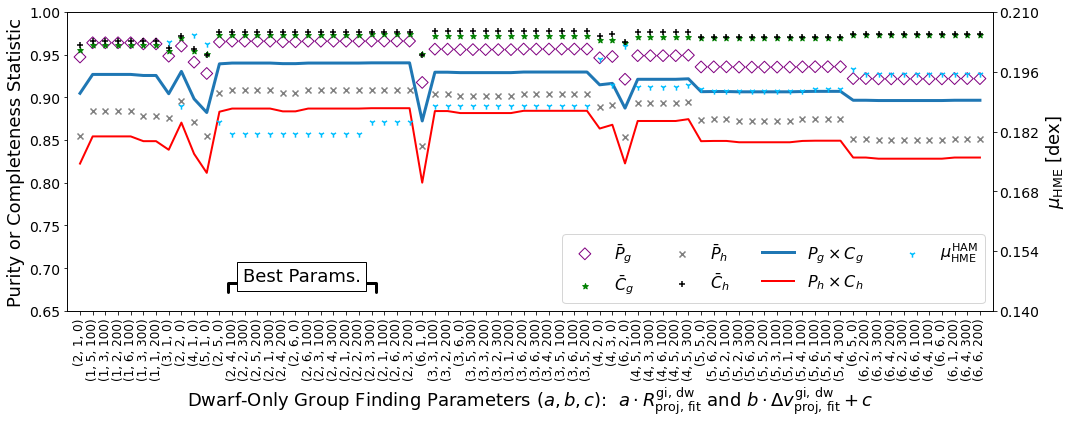

In [17]:
fig,(ax1)=plt.subplots(figsize=(15,6),sharex=True)
myrange=np.arange(1,len(pg)+1)
ax1.scatter(myrange-1,pggt1,edgecolors='purple',facecolors='None',marker='D',label=r'$\bar{P}_g$',s=70)
ax1.scatter(myrange-1,cggt1,color='green',marker='*', label=r'$\bar{C}_g$')
ax1.scatter(myrange-1,phgt1,color='gray',marker='x', label=r'$\bar{P}_h$')
ax1.scatter(myrange-1,chgt1,color='k',marker='+', label=r'$\bar{C}_h$',s=30)
ax1.plot(myrange-1,pggt1timescggt1,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax1.plot(myrange-1,phgt1timeschgt1,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax1twin=ax1.twinx()
ax1twin.scatter(myrange-1,mugt1,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1twin.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=18)
#ax1.set_ylim(0.8,1)
ytvals = np.arange(0.65,1.05,0.05)
ax1.set_yticks(ytvals, ["{:0.2f}".format(x) for x in ytvals], fontsize=14)
ax1.set_ylim(0.65,1)
hme_ylim = [0.14,0.21]#[min(mugt1),max(mugt1)]
step=(hme_ylim[1]-hme_ylim[0])/5.
ax1twin.set_ylim(*hme_ylim)
hme_ytvals = np.arange(hme_ylim[0],hme_ylim[1]+step,step)
ax1twin.set_yticks(hme_ytvals, ["{:0.3f}".format(x) for x in hme_ytvals], fontsize=14)

ax1.set_xlabel(r"Dwarf-Only Group Finding Parameters $(a,b,c)$:  $a\cdot R_{\rm proj,\, fit}^{\rm gi,\, dw}$ and $b \cdot \Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}+c$",fontsize=18)
ax1.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=12)
ax1.set_ylabel(r"Purity or Completeness Statistic",fontsize=18)
#fig.text(-0.01, 0.6, 'Purity or Completeness Statistic', va='center', rotation='vertical',fontsize=18)
ax1.set_xlim(np.min(myrange-2),np.max(myrange))
#ax.annotate(r"Parameters $(a,b,c)$:  $a\cdot R_{\rm proj,\, fit}^{\rm gi,\, dw}$ and $b \cdot \Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}+c$",\
#            xy=(7,0.945),fontsize=18)
#ax1.annotate(r"$N_{\rm dwarfs}=1$ Groups Excluded",xy=(40,0.81),fontsize=18)
ax1.scatter(0,0,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.legend(loc='lower right',ncol=4,fontsize=16)
ax1.annotate(r'Best Params.', xy=(17.5,0.68), 
            fontsize=18, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white'),
            arrowprops=dict(arrowstyle='-[, widthB=4.1, lengthB=0.5', lw=3.0))
plt.tight_layout()
plt.savefig("../figures/optimal_params_dwarfs.pdf",dpi=300)
plt.show()

In [ ]:
# fig,ax=plt.subplots(figsize=(15,6))
# myrange=np.arange(1,len(pg)+1)
# ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label=r'$\bar{P}_g$',s=70)
# ax.scatter(myrange-1,cg,color='green',marker='*', label=r'$\bar{C}_g$')
# ax.scatter(myrange-1,ph,color='gray',marker='x', label=r'$\bar{P}_h$')
# ax.scatter(myrange-1,ch,color='k',marker='+', label=r'$\bar{C}_h$',s=30)
# ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=1,label=r'$\bar{P}_g \times \bar{C}_g$')
# ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$\bar{P}_h \times \bar{C}_h$')
# ax.set_xlim(-1,max(myrange)+1)
# axtwin=ax.twinx()
# axtwin.scatter(myrange-1,mu,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# axtwin.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=18)
# ax.set_ylim(0.9,1.)
# ytvals = np.arange(0.9,1.005,0.01)
# ax.set_yticks(ytvals, ["{:0.2f}".format(x) for x in ytvals], fontsize=14)
# hme_ylim = [0.161,0.166]
# step=(hme_ylim[1]-hme_ylim[0])/5.
# axtwin.set_ylim(*hme_ylim)
# hme_ytvals = np.arange(hme_ylim[0],hme_ylim[1]+step,step)
# axtwin.set_yticks(hme_ytvals, ["{:0.3f}".format(x) for x in hme_ytvals], fontsize=14)

# ax.set_xlabel(r"Dwarf-Only Group Finding Parameters $(a,b,c)$:  $a\cdot R_{\rm proj,\, fit}^{\rm gi,\, dw}$ and $b \cdot \Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}+c$",fontsize=18)
# ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=12)
# #fig.text(-0.01, 0.6, 'Purity or Completeness Statistic', va='center', rotation='vertical',fontsize=18)
# ax.set_ylabel("Purity or Completeness Statistic",fontsize=18)
# ax.legend(loc='lower right', framealpha=1, fontsize=16, ncol=4)
# #ax.annotate(r"Parameters $(a,b,c)$:  $a\cdot R_{\rm proj,\, fit}^{\rm gi,\, dw}$ and $b \cdot \Delta v_{\rm proj,\, fit}^{\rm gi,\, dw}+c$",\
# #            xy=(7,0.945),fontsize=18)
# #ax.annotate(r"$N_{\rm dwarfs}=1$ Groups Included",xy=(15,0.935),fontsize=18)
# #ax1.annotate(r"$N_{\rm dwarfs}=1$ Groups Excluded",xy=(15,0.72),fontsize=18)
# ax.legend(loc='lower right', framealpha=1, fontsize=18, ncol=4)
# # ax.annotate(r'Best', xy=(23,0.94), 
# #             fontsize=18, ha='center', va='bottom',
# #             bbox=dict(boxstyle='square', fc='white'),
# #             arrowprops=dict(arrowstyle='-[, widthB=4.8, lengthB=-.2', lw=3.0))
# plt.tight_layout()
# plt.savefig("../figures/optimal_params_dwarfs.pdf",dpi=300)
# plt.show()

In [ ]:
max(cg)

In [ ]:
max(ch)

In [ ]:
min(mu)